# MediCheck AI - Exploratory Data Analysis & Baseline



## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup visualisasi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid")
%matplotlib inline

## 2. Load Dataset

In [2]:
data_path = '../data/raw/diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
df = pd.read_csv(data_path)

print(f"Dimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Dimensi dataset: 70692 baris, 22 kolom


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


## 3. Struktur Data & Ringkasan Statistik

In [3]:
print("--- Info Dataset ---")
df.info()

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15

In [4]:
print("--- Statistik Deskriptif ---")
df.describe().T

--- Statistik Deskriptif ---


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


In [5]:
print("--- Pengecekan Missing Values ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Tidak ada missing values pada dataset!")

--- Pengecekan Missing Values ---
Tidak ada missing values pada dataset!


## 4. Analisis Distribusi Target Class (`Diabetes_binary`)

C:\Users\dzaki\AppData\Local\Temp\ipykernel_44968\4159461251.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette='viridis', ax=ax[0])


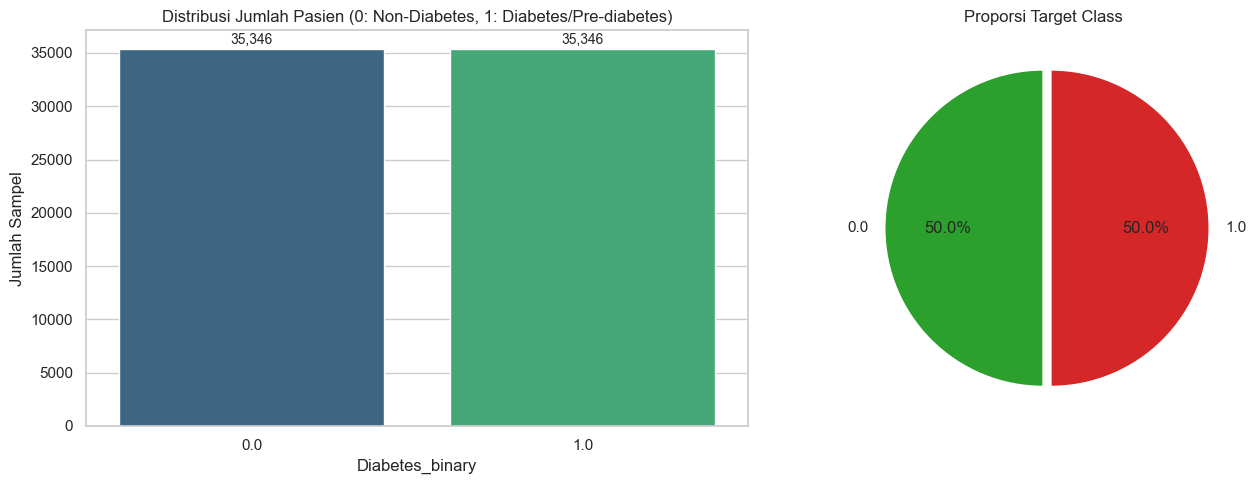

In [6]:
target_col = 'Diabetes_binary'

if target_col in df.columns:
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # Countplot
    sns.countplot(data=df, x=target_col, palette='viridis', ax=ax[0])
    ax[0].set_title('Distribusi Jumlah Pasien (0: Non-Diabetes, 1: Diabetes/Pre-diabetes)', fontsize=12)
    ax[0].set_xlabel('Diabetes_binary')
    ax[0].set_ylabel('Jumlah Sampel')
    
    # Anotasi angka pada bar countplot
    for p in ax[0].patches:
        ax[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontsize=10)
    
    # Pie Chart Persentase
    df[target_col].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[1], colors=['#2ca02c', '#d62728'], explode=[0, 0.05], startangle=90)
    ax[1].set_title('Proporsi Target Class', fontsize=12)
    ax[1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Kolom target '{target_col}' tidak ditemukan di dataset.")